# 위약검정 — 법인 축 (인천e음 사용 불가 집단)

**질문** 인천e음을 쓸 수 없는 **법인**(`GENDER_CD = x`)에서도 캐시백 대상 업종의 인천 추가 감소(DDD)가 나타나는가. 대체효과라면 법인에서는 0이어야 한다.

**규약** `CLAUDE.md` 계산 규약. PRE = 1~4월, POST = 5~6월 **월평균**, 대조군은 인천 제외, C = 대형할인점, T = 나머지 10개 업종. 이천시는 로드 단계에서 제거.

**구성**
1. 규모와 대조군 안정성
2. 수동 DiD·DDD — 대조군 3종
3. 회귀 DDD — 시군구×업종 FE + 월×업종 FE, 시군구 클러스터 SE
4. 시군구 분포에서 인천의 위치
5. 판정

## 0. 환경 설정

In [1]:
import pandas as pd, numpy as np, statsmodels.api as sm, warnings
import matplotlib.pyplot as plt, matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Apple SD Gothic Neo'
mpl.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('../data/ABP_CONTEST_DATA.csv', dtype={'GENDER_CD': str})
PRE  = [202601, 202602, 202603, 202604]
POST = [202605, 202606]
df['grp']     = np.where(df.TP_BUZ_NM == '대형할인점', 'C', 'T')
df['post']    = df.STRD_YYMM.isin(POST).astype(int)
df['incheon'] = (df.SIDO_NM == '인천광역시').astype(int)
df['region']  = df.SIDO_NM + ' ' + df.CCG_NM
df = df[~((df.SIDO_NM == '경기도') & (df.CCG_NM == '이천시'))]   # 확정 배제 대조군
corp = df[df.GENDER_CD == 'x'].copy()
print('법인 행수', len(corp), '| 인천', corp.incheon.sum(), '| 금액 비중', f'{corp.amt.sum() / df.amt.sum() * 100:.2f}%')

법인 행수 13107 | 인천 508 | 금액 비중 6.15%


In [2]:
def rate(d):
    return (d[d.post == 1].amt.sum() / 2) / (d[d.post == 0].amt.sum() / 4) * 100 - 100

def ddd(reg, ctrl):
    T = lambda d: d[d.grp == 'T']; C = lambda d: d[d.grp == 'C']
    r = dict(인천T=rate(T(reg)), 대조T=rate(T(ctrl)), 인천C=rate(C(reg)), 대조C=rate(C(ctrl)))
    r['DiD_T'] = r['인천T'] - r['대조T']; r['DiD_C'] = r['인천C'] - r['대조C']; r['DSI'] = r['DiD_T'] - r['DiD_C']
    return r

def samples(d):   # 인천 포함 표본 (회귀용)
    return {'전국 전체': d,
            '부산·경남 제외': d[~d.SIDO_NM.isin(['부산광역시', '경상남도'])],
            '수도권만': d[d.SIDO_NM.isin(['서울특별시', '경기도', '인천광역시'])]}

## 1. 규모와 대조군 안정성

In [3]:
sido = corp.groupby('SIDO_NM').apply(rate, include_groups=False).sort_values()
print(f'인천 {rate(corp[corp.incheon == 1]):.2f}% | 전국(인천 제외) {rate(corp[corp.incheon == 0]):.2f}% | 인천 시도 순위(낮은 순) {int(sido.rank()["인천광역시"])}/17')
sido.to_frame('법인 증감률(%)').T

인천 9.11% | 전국(인천 제외) 74.53% | 인천 시도 순위(낮은 순) 3/17


SIDO_NM,세종특별자치시,대구광역시,인천광역시,충청북도,경상북도,대전광역시,서울특별시,경기도,충청남도,강원특별자치도,전북특별자치도,광주광역시,제주특별자치도,전라남도,울산광역시,부산광역시,경상남도
법인 증감률(%),6.56,8.88,9.11,11.57,13.67,17.08,19.09,22.46,26.38,31.56,34.25,68.72,109.87,206.75,208.66,301.42,592.56


- 인천 법인 +9.1%, 17개 시도 중 하위 3위. 내국인(−2.8%, 유일한 마이너스)과 달리 플러스.
- 대조군 시도 증감률이 **+7~+593%**로 극단적(경남·부산·울산·전남 급증). 법인의 금액 가중 비교는 대조군 선택에 크게 흔들린다.

## 2. 수동 DiD·DDD

In [4]:
inc = corp[corp.incheon == 1]
manual = pd.DataFrame({k: ddd(inc, v[v.incheon == 0]) for k, v in samples(corp).items()}).T
manual

,인천T,대조T,인천C,대조C,DiD_T,DiD_C,DSI
전국 전체,10.35,79.03,-2.10,1.01,-68.68,-3.11,-65.57
부산·경남 제외,10.35,35.98,-2.10,1.34,-25.64,-3.44,-22.20
수도권만,10.35,23.28,-2.10,0.47,-12.93,-2.57,-10.36


## 3. 회귀 DDD
셀 = 시군구 × 업종 × 월, 종속변수 log(amt). 셀 균등 가중이라 대조군 금액 급증에 덜 휘둘린다.
```
log(Y) = β₄(Post×인천) + β₇(Post×인천×대상) + 시군구×업종 FE + 월×업종 FE + ε
```

In [5]:
def cells(d):
    c = d.groupby(['region', 'TP_BUZ_NM', 'STRD_YYMM', 'incheon', 'post', 'grp'], as_index=False).amt.sum()
    c['y']   = np.log(c.amt)
    c['pi']  = c.post * c.incheon                       # β4: Post × 인천
    c['pit'] = c.pi * (c.grp == 'T')                    # β7: Post × 인천 × 대상
    c['ri']  = c.region + '|' + c.TP_BUZ_NM             # 시군구×업종 FE
    c['mi']  = c.STRD_YYMM.astype(str) + '|' + c.TP_BUZ_NM   # 월×업종 FE
    return c

def demean2(X, f1, f2, tol=1e-9, maxit=500):
    for _ in range(maxit):
        X0 = X
        X = X - X.groupby(f1).transform('mean')
        X = X - X.groupby(f2).transform('mean')
        if (X - X0).abs().max().max() < tol:
            break
    return X

def fe_reg(c, xs):
    Y = demean2(c[['y'] + xs].astype(float), c.ri, c.mi)
    m = sm.OLS(Y.y, Y[xs]).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(c.region)[0]})
    return pd.DataFrame({'coef': m.params, 'se': m.bse, 'p': m.pvalues})

rows = []
for k, d in samples(corp).items():
    c = cells(d); r = fe_reg(c, ['pi', 'pit'])
    rows.append({'대조군': k, 'n셀': len(c),
                 'β4 대형할인점(%)': np.expm1(r.coef.pi) * 100, 'β4 p': r.p.pi,
                 'β7 대상업종(%)': np.expm1(r.coef.pit) * 100, 'β7 p': r.p.pit,
                 'β7 CI 하한(%)': np.expm1(r.coef.pit - 1.96 * r.se.pit) * 100,
                 'β7 CI 상한(%)': np.expm1(r.coef.pit + 1.96 * r.se.pit) * 100})
reg = pd.DataFrame(rows).set_index('대조군')
reg

,n셀,β4 대형할인점(%),β4 p,β7 대상업종(%),β7 p,β7 CI 하한(%),β7 CI 상한(%)
대조군,,,,,,,
전국 전체,13107,-1.05,0.71,-32.46,0.00,-38.95,-25.28
부산·경남 제외,11028,-1.64,0.58,-15.67,0.00,-21.57,-9.31
수도권만,4329,-0.96,0.76,-10.52,0.00,-15.71,-5.00


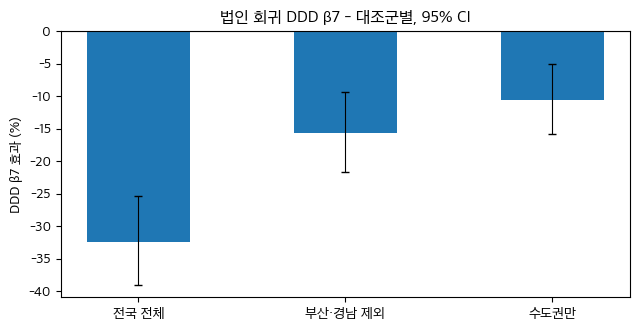

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
x = np.arange(len(reg)); b = reg['β7 대상업종(%)'].values
ax.bar(x, b, 0.5, color='C0')
ax.errorbar(x, b, yerr=[b - reg['β7 CI 하한(%)'], reg['β7 CI 상한(%)'] - b], fmt='none', ecolor='k', capsize=3, lw=0.8)
ax.axhline(0, color='grey', lw=0.8); ax.set_xticks(x); ax.set_xticklabels(reg.index)
ax.set_ylabel('DDD β7 효과 (%)'); ax.set_title('법인 회귀 DDD β7 - 대조군별, 95% CI')
plt.tight_layout(); plt.show()

- 수동 DiD_T −13~−69%p로 대조군마다 크게 흔들린다. 회귀 β₇는 −10~−32%로 **모두 유의**.
- 대형할인점 β₄는 −1~−2%로 0 근처. 즉 T 업종에서만 인천이 상대적으로 낮다.
- 대조군을 좁힐수록(급증 지역 제외) β₇가 −32 → −10%로 줄어든다 → 효과 크기 상당 부분이 대조군 법인 급증에서 온다.

## 4. 시군구 분포에서 인천의 위치
대조군 급증에 휘둘리지 않도록, 법인 T 업종 시군구 증감률 분포에서 인천 8개 구의 순위를 본다.

In [7]:
g = corp[corp.grp == 'T'].groupby(['region', 'post']).amt.sum().unstack().dropna()
r = (g[1] / 2) / (g[0] / 4) * 100 - 100
rk = r.rank(); n = len(r)
urban = r[r.index.str.startswith('인천') & ~r.index.str.contains('강화|옹진')]
print(f'시군구 {n}곳, 중앙값 {r.median():.1f}%, 하위 10% 경계 {r.quantile(.1):.1f}%')
pd.DataFrame({'증감률(%)': urban, '순위': rk[urban.index].astype(int), '백분위': (rk[urban.index] / n * 100).round(0)})

시군구 254곳, 중앙값 24.5%, 하위 10% 경계 2.1%


,증감률(%),순위,백분위
region,,,
인천광역시 계양구,6.87,32,13.00
인천광역시 남동구,2.61,27,11.00
인천광역시 동구,8.79,39,15.00
인천광역시 미추홀구,9.24,41,16.00
인천광역시 부평구,7.35,35,14.00
인천광역시 서구,10.60,46,18.00
인천광역시 연수구,23.69,118,46.00
인천광역시 중구,5.29,29,11.00


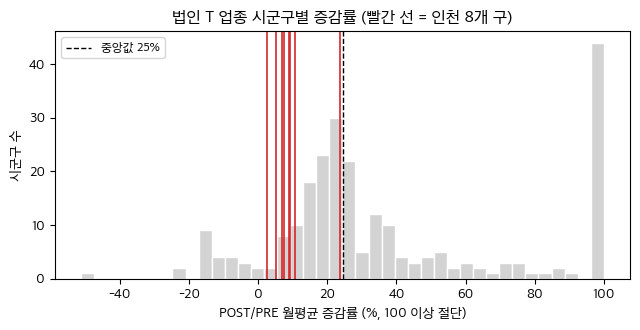

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
rc = r.clip(upper=100)
ax.hist(rc[~rc.index.str.startswith('인천')], bins=40, color='lightgrey', edgecolor='white')
for v in rc[urban.index]: ax.axvline(v, color='C3', lw=1.2)
ax.axvline(r.median(), color='k', ls='--', lw=1, label=f'중앙값 {r.median():.0f}%')
ax.set_title('법인 T 업종 시군구별 증감률 (빨간 선 = 인천 8개 구)')
ax.set_xlabel('POST/PRE 월평균 증감률 (%, 100 이상 절단)'); ax.set_ylabel('시군구 수'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

- 인천 8개 구가 하위 11~46% 백분위로 분포 안쪽. 중앙값(+24%)보다 낮을 뿐 이례적이지 않다.
- 내국인은 같은 방식에서 하위 1~7%에 몰렸다. 법인에는 그런 시 단위 충격이 보이지 않는다.

## 5. 판정

| 항목 | 결과 |
|---|---|
| 인천 법인 절대 증감률 | +9.1% (시도 하위 3위) |
| 대조군 법인 시도 증감률 | +7~+593% (경남·부산 급증) |
| 수동 DSI (전국 / 부산·경남 제외 / 수도권) | −65.6 / −22.2 / −10.4%p |
| 회귀 β₇ | −32.5 / −15.7 / −10.5% (모두 p<.01) |
| 시군구 백분위 | 11~46% (분포 안쪽) |

**판정: 대조군 이상으로 판정 불가.** "통과"도 "실패"도 아니다.
1. 회귀 DDD는 유의한 음수지만, 대조군 법인 소비가 5~6월 전국적으로 급증해 어떤 대조군에서도 인천이 상대적으로 낮게 나온다.
2. 절대 수준(+9%)과 시군구 순위(분포 안쪽)로 "내국인과 같은 시 단위 충격은 없었다"까지만 주장한다.
3. 법인 급증 원인 `(확인 필요)` — 확인 전까지 한계 표에 반례로 기재.